<center>
<h1><b>Prompt Engineering </b>
<h1><b>Classification tasks : Sentiment Analysis </b>
</center>

# Learning Objectives

This tutorial introduces Large Language Models (LLMs) as powerful tools for classification tasks, with a focus on sentiment analysis. By the end of this notebook, you will:

- Understand how LLMs can be leveraged for classification problems beyond traditional machine learning approaches.
- Learn the fundamentals of prompt engineering to guide LLMs for accurate sentiment analysis.
- Explore techniques for aspect-based sentiment analysis on product reviews.
- Evaluate LLM performance on classification tasks using metrics like F1-score.
- Compare different LLMs (OpenAI GPT models, Groq) for classification tasks.
- Gain hands-on experience in setting up API keys, token counting, and making API calls to LLMs.

This notebook assumes basic knowledge of Python and machine learning concepts. We'll use libraries like LangChain for LLM interactions and scikit-learn for evaluation.

# Introduction to Prompt Engineering for Classification

Welcome to this comprehensive tutorial on using Large Language Models (LLMs) for classification tasks, specifically sentiment analysis. In recent years, LLMs have revolutionized natural language processing, offering powerful capabilities for understanding and generating human-like text.

Classification tasks involve assigning categories or labels to input data. Traditional approaches use machine learning models trained on labeled datasets, but LLMs provide an alternative that can often achieve high accuracy with minimal training data through careful prompt design.

This notebook will guide you through:
- Setting up your development environment with necessary libraries and API access
- Understanding tokenization and its importance for LLM interactions
- Crafting effective prompts for sentiment analysis
- Implementing aspect-based sentiment analysis for product reviews
- Evaluating model performance and comparing different LLMs
- Best practices for prompt engineering in classification tasks

By the end, you'll have a solid foundation for applying LLMs to various classification problems in your own projects.

# Prompt Engineering Workflow

Effective prompt engineering is crucial for getting reliable results from LLMs. This notebook follows a structured approach:

1. **Prepare Data**: Load and preprocess datasets for classification tasks. We'll use the Hugging Face datasets library to load sentiment analysis data.

2. **Devise Prompts**: Craft clear, specific prompts that guide the LLM to perform the desired classification. This includes system messages, user templates, and examples (few-shot learning).

3. **Evaluate Prompts**: Test prompts on validation data, measure performance using classification metrics, and iterate to improve accuracy.

Throughout this tutorial, we'll apply this workflow to sentiment analysis and aspect-based sentiment analysis tasks.

# Setting Up the Environment

Before we dive into prompt engineering, let's set up our development environment with the necessary libraries and tools.

## Required Libraries and Dependencies

We'll use several key libraries in this tutorial:

- **openai**: Official OpenAI Python client for accessing GPT models
- **langchain**: Framework for building applications with LLMs
- **datasets**: Hugging Face library for loading and managing datasets
- **pandas/numpy**: Data manipulation and analysis
- **scikit-learn**: Machine learning utilities for evaluation
- **tiktoken**: OpenAI's tokenizer for counting tokens
- **python-dotenv**: For securely loading API keys from environment variables

Make sure to install these packages using pip or conda before running the notebook.

In [14]:
import openai
import json
import tiktoken
import session_info
import pandas as pd
import numpy as np
from datasets import load_dataset
from collections import Counter
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from langchain_community.llms import Ollama
from dotenv.ipython import load_dotenv
import os

## Understanding the Imports

The code above imports all necessary libraries for our LLM experiments:

- **LLM Providers**: `ChatOpenAI` and `ChatGroq` for interacting with different LLM APIs
- **Data Handling**: `pandas`, `numpy`, and `datasets` for data manipulation
- **Evaluation**: `sklearn` metrics for assessing model performance
- **Utilities**: `tiktoken` for token counting, `dotenv` for secure API key management

Next, we'll check our environment and session information.

In [15]:
session_info.show()

c:\Users\Legion\miniconda3\envs\env_agent\Lib\site-packages\session_info\main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


# API Configuration and Security

## Setting Up API Keys

To use LLMs from providers like OpenAI and Groq, you need API keys. These keys authenticate your requests and are billed based on usage.

### Best Practices for API Key Management:
1. **Never hardcode keys in your code** - they could be accidentally committed to version control
2. **Use environment variables** - store keys in a `.env` file that's ignored by git
3. **Limit key permissions** - use restricted keys when possible
4. **Rotate keys regularly** - change keys periodically for security

### Required API Keys:
- **OPENAI_API_KEY**: For accessing OpenAI's GPT models
- **GROQ_API_KEY**: For accessing Groq's fast inference models

Create a `.env` file in your project directory with:
```
OPENAI_API_KEY=your_openai_key_here
GROQ_API_KEY=your_groq_key_here
```

The `load_dotenv()` function loads these into your environment securely.

# Exploring Large Language Models

## Overview of LLMs Used in This Tutorial

We'll work with several state-of-the-art LLMs, each with different strengths:

### OpenAI GPT-4o
- **Capabilities**: Excellent at understanding context and generating coherent responses
- **Use Case**: General-purpose tasks, complex reasoning
- **Pricing**: Pay-per-token usage
- **API**: Requires OpenAI API key

### Groq Models (e.g., llama3-70b-8192)
- **Capabilities**: Fast inference, good performance on various tasks
- **Use Case**: Cost-effective alternative for high-throughput applications
- **Pricing**: Competitive rates, often faster than OpenAI
- **API**: Requires Groq API key

### Key Considerations:
- **Temperature**: Set to 0 for deterministic, classification-focused tasks
- **Max Tokens**: Limits response length to control costs
- **System Messages**: Guide the model's behavior and role
- **Few-shot Learning**: Provide examples to improve accuracy

We'll compare these models on sentiment analysis tasks to understand their relative strengths.

# Understanding Tokenization

## Why Tokens Matter

LLMs process text by breaking it into tokens - subword units that can be words, parts of words, or punctuation. Understanding tokenization is crucial because:

1. **Cost Control**: API costs are based on token usage (input + output)
2. **Context Limits**: Models have maximum context windows measured in tokens
3. **Performance**: Efficient tokenization affects processing speed
4. **Prompt Design**: Knowing token counts helps optimize prompt length

## Tokenization with TikToken

OpenAI provides the `tiktoken` library for accurate token counting using the same tokenizer as their models.

### Key Concepts:
- **Encoding**: Converting text to tokens
- **Decoding**: Converting tokens back to text
- **Token Count**: Number of tokens in a piece of text

The example below shows how to count tokens for a system message used in sentiment analysis.

In [16]:
encoding = tiktoken.encoding_for_model("gpt-4-turbo")
system_message =""" 
Peform Sentiment analysis of the revview presented in the user message.
The result should be positive or negative. Do not justify your response
"""
print(encoding.encode(system_message))

[720, 10407, 630, 24248, 3904, 6492, 315, 279, 5891, 1068, 10666, 304, 279, 1217, 1984, 627, 791, 1121, 1288, 387, 6928, 477, 8389, 13, 3234, 539, 9541, 701, 2077, 198]


# Testing OpenAI GPT-4o for Aspect-Based Sentiment Analysis

## Aspect-Based Sentiment Analysis

Unlike simple sentiment analysis (positive/negative overall), aspect-based analysis identifies sentiments toward specific aspects or features of a product.

### Task Description:
- **Input**: Laptop reviews mentioning screen, keyboard, and/or mousepad
- **Output**: JSON with categories (aspects found) and their polarities (positive/negative/neutral)

### Prompt Engineering Strategy:
1. **Clear Instructions**: Specify the task and expected output format
2. **Structured Output**: Require JSON format for easy parsing
3. **Few-shot Examples**: Provide examples to guide the model
4. **Aspect Focus**: Limit to specific aspects (screen, keyboard, mousepad)

The prompt below demonstrates this approach with LangChain's ChatOpenAI interface.

In [17]:
load_dotenv(override=True)

True

In [19]:
gpt4_llm = ChatOpenAI(model="gpt-4o", temperature=0)
system_message = """
Perform aspect based sentiment analysis on laptop reviews presented in the input delimited by triple backticks, that is, ```.
In each review there might be one or more of the following aspects: screen, keyboard, and mousepad.
For each review presented as input:
- Identify if there are any of the 3 aspects (screen, keyboard, mousepad) present in the review.
- Assign a sentiment polarity (positive, negative or neutral) for each aspect, Arrange your response a JSON object with the following headers:
- category:[list of aspects]
- polarity:[list of corresponding polarities for each aspect]
"""
prompt = [
  {"role": "system", "content": system_message},
  {"role": "user", "content": """
 ```The screen is good. The keyboard is bad and the mousepad is quite```
       """}, 
  {"role": "assistant", "content": """
      {'category':['screen','keyboard','mousepad'],'polarity':['positive','negative','neutral’]}
      """},
  {"role": "user", "content": """
       ```I am impressed by the quality of the screen. disappointed with the keyboard, 
          but the mousepad is of very good quality```
       """}
]

response = gpt4_llm.invoke(prompt)
print(response.content)

```json
{
  "category": ["screen", "keyboard", "mousepad"],
  "polarity": ["positive", "negative", "positive"]
}
```


# Direct API Calls to OpenAI

## Using the OpenAI REST API

While libraries like LangChain provide convenient interfaces, understanding direct API calls gives you more control and helps with debugging.

### Key Components of an API Request:
- **Headers**: Include Content-Type and Authorization (Bearer token)
- **Payload**: Model specification, messages, and parameters
- **Messages**: System prompt + user input
- **Parameters**: temperature, max_tokens, etc.

### Advantages of Direct API Calls:
- Full control over request structure
- Better error handling
- Access to all API features
- Easier integration with custom workflows

This example shows a simple sentiment classification using the requests library.

In [23]:
import os
import requests
from dotenv import load_dotenv

load_dotenv(override=True)

# Read the API key securely. Make sure the name inside getenv() 
# exactly matches the variable name declared in your .env file
api_key = os.getenv("OPENAI_API_KEY") # e.g. OPEN_AI_KEY=sk-... in the .env file

system_message = """ 
Classify the sentiment of the review presented in the input as 'positive' or 'negative'
The review will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.
"""
user_message_template = "```{review}```"
user_message = "I think that your services are very fine"

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {api_key}"
}

payload = {
    "model": "gpt-4o",
    "messages": [
        {
            "role": "system",
            "content": system_message
        },
        {
            "role": "user",
            "content": user_message_template.format(review=user_message)
        }
    ],
    "max_tokens": 300,
    "temperature": 0
}

response = requests.post("https://api.openai.com/v1/chat/completions", headers=headers, json=payload)

print(response.json()['choices'][0]['message']['content'])


positive


# Testing Groq Models

## Groq: Fast Inference for LLMs

Groq provides accelerated inference for various open-source LLMs, offering competitive performance at lower costs than proprietary models.

### Advantages of Groq:
- **Speed**: Significantly faster response times
- **Cost**: Often more economical for high-volume usage
- **Models**: Access to models like Llama, Mixtral, and others
- **API Compatibility**: Similar interface to OpenAI's API

### Model Selection:
We'll use `openai/gpt-oss-120b` - a high-performance model optimized for various tasks.

The code below sets up a Groq model for sentiment analysis comparison.

In [ ]:
groq_llm = ChatGroq(model_name="openai/gpt-oss-120b", temperature=0)
system_message =""" 
Classify the sentiment of the review presented in the input as 'positive' or 'negative'
The review will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.
"""
user_message_template ="```{review}```"
user_message ="I think that your services are very fine"
zero_shot_prompt = [
    {"role":"system","content":system_message},
    {"role":"user", "content":user_message_template.format(review=user_message)},
]
response = groq_llm.invoke(zero_shot_prompt)
print(response.content.replace("</s>",""))

positive


# Multimodal Capabilities: Image Description with GPT-4 Vision

## Beyond Text: Vision-Language Models

Modern LLMs like GPT-4o can process both text and images, enabling powerful multimodal applications.

### Vision Tasks:
- **Image Description**: Generate detailed descriptions of images
- **Object Detection**: Identify objects, people, and scenes
- **OCR**: Extract text from images
- **Visual Question Answering**: Answer questions about image content

### Implementation Details:
- **Base64 Encoding**: Images are encoded as base64 strings for API transmission
- **Structured Output**: Use JSON format for consistent parsing
- **Prompt Engineering**: Clear instructions for what to analyze

This example demonstrates counting people and genders in an image using structured JSON output.

In [34]:
import base64
import requests

api_key = os.getenv("OPENAI_API_KEY") # e.g. OPEN_AI_KEY=sk-... in the .env file

# Function to encode the image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

# Path to your image
image_path = "student.png"

# Getting the base64 string
base64_image = encode_image(image_path)

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {api_key}"
}

prompt_text = """
Donne moi une description de cette image. Le résultat sera au format json avec les champs suivants :
 - Description : Une description de l'image 
 - Nombre de personnes dans l'image
 - Nombre de filles
 - Nombre de garçon
""" 
payload = {
    #"model": "gpt-4-vision-preview",
    "model": "gpt-4o",
    "response_format": {"type": "json_object"},
    "messages": [
      {
        "role": "user",
        "content": [
          {
            "type": "text",
            "text": prompt_text
          },
          {
            "type": "image_url",
            "image_url": {
              "url": f"data:image/jpeg;base64,{base64_image}"
            }
          }
        ]
      }
    ],
    "max_tokens": 300
}

response = requests.post("https://api.openai.com/v1/chat/completions", headers=headers, json=payload)

if response.status_code == 200:
    # Success
    print(response.json()['choices'][0]['message']['content'])
else:
    # Failure -> print the detailed error reason
    print(f"Error {response.status_code}:")
    print(response.json())


{
  "Description": "L'image montre un schéma de circuit imprimé (PCB) avec des composants électroniques disposés sur une carte. Les composants sont identifiés par des étiquettes alphanumériques telles que JDIMM1, UC1, et JKB1. La disposition est complexe et inclut divers connecteurs et puces.",
  "Nombre de personnes dans l'image": 0,
  "Nombre de filles": 0,
  "Nombre de garçon": 0
}


# Creative Generation: Image Creation with DALL-E

## Text-to-Image Generation

DALL-E models can create images from text descriptions, opening possibilities for creative applications.

### Key Features:
- **High Quality**: Generate detailed, realistic images
- **Style Control**: Specify artistic styles (anime, realistic, etc.)
- **Composition**: Control scene elements and layouts
- **Variations**: Generate multiple versions of the same concept

### API Parameters:
- **Model**: dall-e-3 for highest quality
- **Prompt**: Detailed description of desired image
- **Size**: 1024x1024, 512x512, etc.
- **Response Format**: URL or base64 encoded image

The example below generates an anime-style character image and displays it in the notebook.

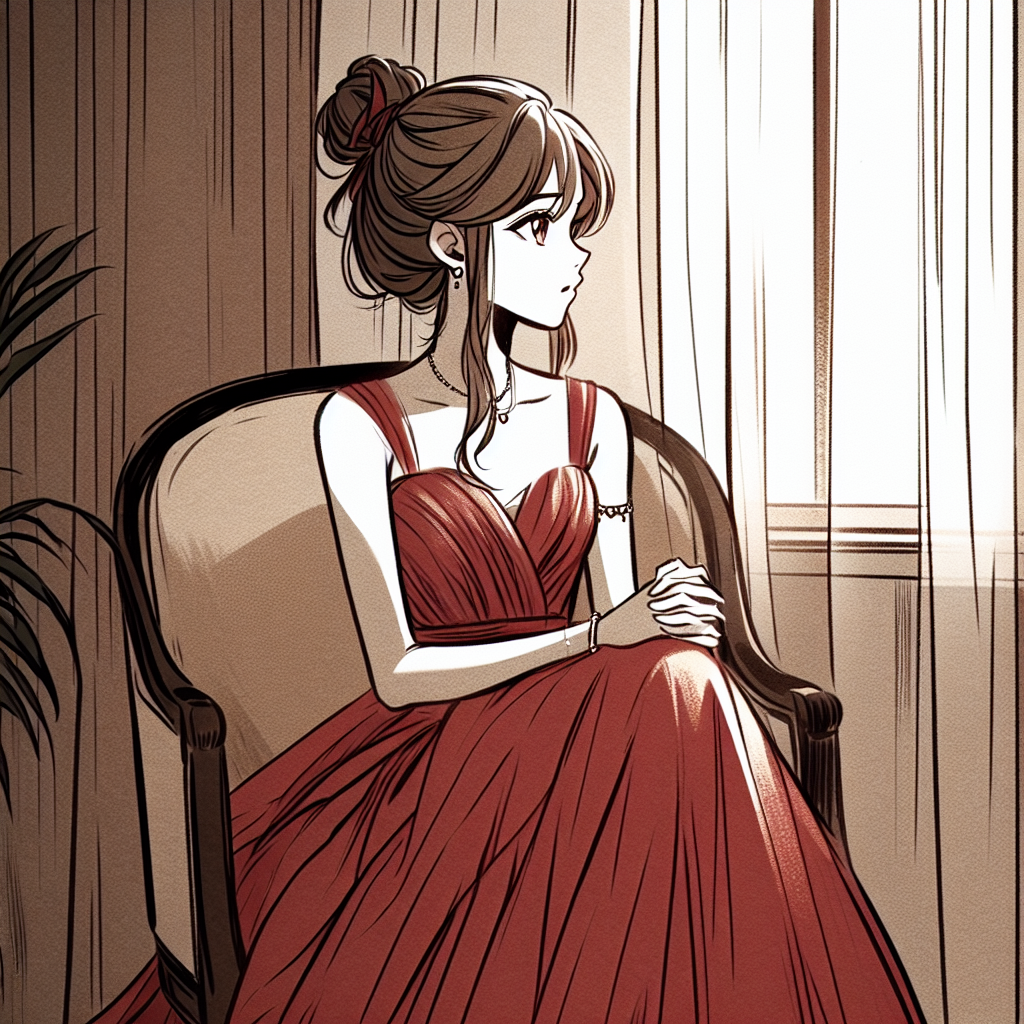

<PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x19E9490FFB0>


In [35]:
import json
import requests
import io
import base64
from PIL import Image
from IPython.display import display

url = "https://api.openai.com/v1/images/generations"

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {api_key}"
}

payload = {
    "model": "dall-e-3",
    "prompt": "Anime girl, Changli, wearing long red dress in a prom WuWa style, sitting in a chair looking at window",
    "response_format":"b64_json",
    "n": 1,
    "size":"1024x1024"
}

response = requests.post(url=f'{url}', headers=headers, json=payload)
image_data = response.json()["data"][0]["b64_json"]
image = Image.open(io.BytesIO(base64.b64decode(image_data)))
image.save('output.png')
display(image)
print(image)

# Step 1: Define Objectives and Evaluation Metrics

## Evaluating Prompt Performance

To determine if our prompts are effective, we need quantitative measures of performance.

### Sentiment Analysis Metrics:
- **Accuracy**: Fraction of correct predictions
- **F1 Score**: Harmonic mean of precision and recall, robust to class imbalance
- **Micro-F1**: Aggregates contributions from all classes equally
- **Macro-F1**: Averages F1 scores across classes, giving equal weight to each class

### Why F1 Score Over Accuracy?
- **Class Imbalance**: Real-world data often has more positive than negative reviews
- **Balanced Evaluation**: F1 considers both false positives and false negatives
- **Practical Relevance**: Better reflects real-world performance

We'll use scikit-learn's implementation for reliable metric calculation.

In sentiment analysis, we assign one of two labels - positive or negative (in some cases one of three labels - positive, negative or neutral) to the text presented as input. As an example use case, we will assign sentiment to customer reviews for products listed in the apparel category on Amazon.

Since our prediction will be one of two labels - positive or negative - we could use the following metrics to measure the performance of a prompt.

- Accuracy score: calculated as the number of correct predictions (i.e., the number of times the prediction matches the ground truth)

- Micro-F1 score: calculated by computing the True Positives (TP), False Negatives (FN), and False Positives (FP) across all classes. This metric is used when we do not suspect class imbalance (for e.g., if we expect that there won't be an overwhelming amount of positive or negative reviews).

In practise, it is preferable to use a nuanced metric such as micro-F1 over plain accuracy.

To illustrate the computation of micro F1 score for a two-class scenario, we can use a confusion matrix. A confusion matrix is a table that shows the number of true positives (TP), false positives (FP), true negatives (TN), and false negatives (FN) for a binary classification problem.

Here is an example of a confusion matrix for a two-class scenario:

| Predicted/Actual | Positive | Negative |
| ---------------- | -------- | -------- |
| Positive | 50 | 10 |
| Negative | 5 | 100 |

To compute the micro F1 score, we first calculate the total number of true positives, false positives, and false negatives across both classes:

- Total true positives = 50
- Total false positives = 10
- Total false negatives = 5

Then, we can calculate the precision, recall, and F1 score for the micro average:

- Micro-precision = Total true positives / (Total true positives + Total false positives) = 50 / (50 + 10) = 0.833
- Micro-recall = Total true positives / (Total true positives + Total false negatives) = 50 / (50 + 5) = 0.909
- Micro-F1 score = 2 * (Micro-precision * Micro-recall) / (Micro-precision + Micro-recall) = 2 * (0.833 * 0.909) / (0.833 + 0.909) = 0.870

Therefore, the micro F1 score for this example is 0.870.

We will use the `f1_score` implementation from `scikit-learn` to evaluate prompts for sentiment analysis in this notebook.

# Step 2: Data Preparation and Assembly

## Working with Real-World Datasets

For meaningful evaluation, we need high-quality labeled data that represents real use cases.

### IMDB Movie Reviews Dataset:
- **Source**: Hugging Face datasets library
- **Content**: Movie reviews from IMDB
- **Labels**: Binary sentiment (positive/negative)
- **Size**: 25,000 training examples
- **Splits**: Train, test, unsupervised

### Data Preparation Steps:
1. **Load Dataset**: Use `datasets.load_dataset()` for easy access
2. **Split Data**: Separate examples for prompting vs. evaluation
3. **Format Conversion**: Convert to pandas DataFrames for analysis
4. **Sampling**: Use subsets for faster iteration during development

This approach ensures our prompts are tested on diverse, realistic data.

For the sentiment analysis exercise, we will use a dataset of movie reviews [scraped from IMDB](https://huggingface.co/datasets/imdb). Our investigation will focus on assigning positive or negative sentiment to movie reviews that customers have posted on IMDB. During prompt engineering, we will use a hold-out set of reviews (i.e., gold examples) to ascertain the quality of the sentiment assignment.

In [36]:
corpus = load_dataset("imdb")

Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 281438.74 examples/s]


In [37]:
corpus

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Note that the dataset is already split into three subsets - train, test and unsupervised (i.e., without label). Machine learning datasets are usually stored this way; however, we do not intend to train a sentiment classifier from scratch, so we focus only on the training data.

When we assemble a dataset for LLM usage, we create splits for examples and gold examples and save these versions for future iterations. Let us see how this process is executed on the `train` subset of the data. To make data wrangling easier, let us convert the train to DataFrames.

In [38]:
train_df = corpus['train'].to_pandas()

In [39]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 390.8 KB


In [40]:
train_df.label.value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

# Dataset Analysis

## Balanced Sentiment Distribution

The IMDB dataset provides a perfectly balanced distribution:
- **12,500 positive reviews** (label 1)
- **12,500 negative reviews** (label 0)

### Importance of Balance:
- **Fair Evaluation**: Equal representation prevents bias toward majority class
- **Reliable Metrics**: Balanced data gives more trustworthy performance measures
- **Realistic Testing**: Prepares prompts for various real-world scenarios

This balance ensures our evaluation metrics accurately reflect prompt quality.

# Data Formatting for LLM Processing

## Converting Labels to Text

While the dataset uses numeric labels (0/1), LLMs work best with natural language.

### Label Conversion:
- **0 → "negative"**: Clear, unambiguous text representation
- **1 → "positive"**: Consistent with common sentiment terminology

### Benefits:
- **Natural Language**: LLMs understand text better than numbers
- **Prompt Clarity**: Explicit labels reduce ambiguity
- **Evaluation Ease**: Direct comparison with model outputs

The `np.where()` function efficiently applies this mapping across the entire dataset.

In [41]:
train_df['sentiment'] = np.where(train_df.label == 1, "positive", "negative")

In [42]:
train_df.sample(6)

,text,label,sentiment
7635,"A film starring Salma Hayek and Colin Farrell,...",0,negative
3006,That song keeps humming in my head. Not the gr...,0,negative
18251,"I really think that this movie is great, perso...",1,positive
5640,"The Film must have been shot in a day,there ar...",0,negative
3211,This was the first Ewan McGregor movie I ever ...,0,negative
23543,This is my favorite show. I think it is utterl...,1,positive


We now have the dataset in the correct format to be parsed by LLM.

In [43]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

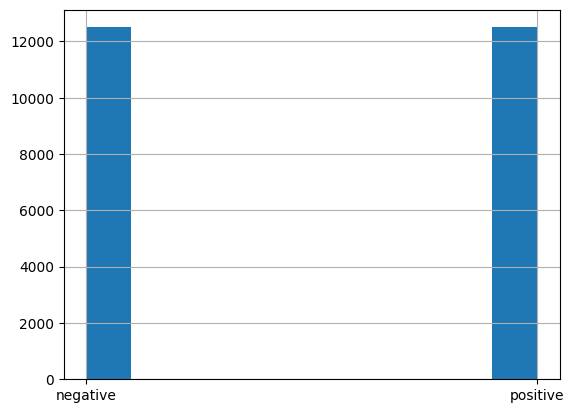

In [45]:
train_df.sentiment.hist()

# Creating Evaluation Splits

## Few-shot Examples vs. Gold Standard

For robust prompt evaluation, we need separate data for different purposes.

### Data Splits:
- **Few-shot Examples**: Used within prompts to guide the model (training-like)
- **Gold Examples**: Held-out data for unbiased evaluation (testing)

### Split Strategy:
- **Random Sampling**: Ensures representative distribution
- **Stratified**: Maintains class balance in both splits
- **Non-overlapping**: Prevents data leakage between training and testing

This approach mimics traditional ML train/test splits but adapted for prompt engineering.

# Data Pipeline Summary

## From Raw Corpus to Evaluation-Ready Dataset

The complete data preparation workflow:

1. **Load Raw Data**: Import from Hugging Face datasets
2. **Format Conversion**: Transform to pandas DataFrame
3. **Label Processing**: Convert numeric to text labels
4. **Split Creation**: Separate examples and gold standard sets
5. **Serialization**: Save in JSON format for reuse

### Best Practices:
- **Version Control**: Track dataset versions for reproducibility
- **Documentation**: Record preprocessing decisions
- **Quality Checks**: Validate splits maintain balance and diversity

This structured approach ensures consistent, reproducible results across different prompt iterations.

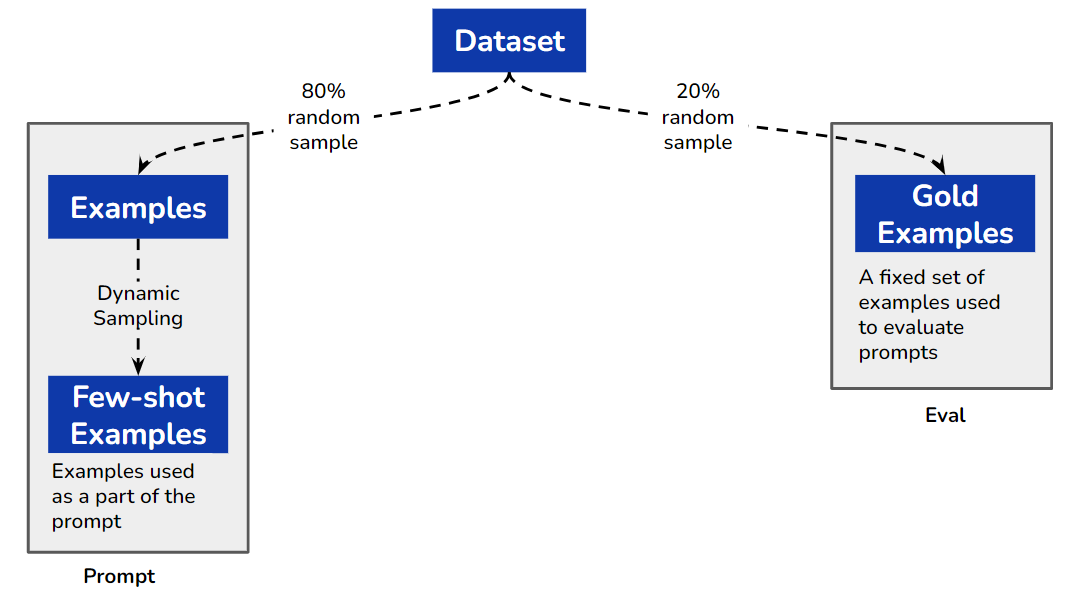

In [46]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=42 
)

In [47]:
(examples_df.shape, gold_examples_df.shape)

((20000, 3), (5000, 3))

To select gold examples for this session, we sample randomly from the test data using a `random_state=42`. This ensures that the examples from multiple runs of the sampling are the same (i.e., they are randomly selected but do not change between different runs of the notebook). Note that we are doing this only to keep execution times low for illustration. In practise, large number of gold examples facilitate robust estimates of model accuracy.

In [48]:
columns= ['text', 'sentiment']
gold_examples = ( gold_examples_df.loc[:, columns].sample(20, random_state=42).to_json(orient='records'))

In [49]:
json.loads(gold_examples)[0]

{'text': 'Like I said at the top, four stars just aren\'t enough. It\'s one of the best films I\'ve ever seen in my almost 17 years of life. For the people that don\'t really like it or understand it, you must not have a real appreciation for art or you might have a short attention span.<br /><br />Even if I haven\'t seen all his films yet, I\'d have to say that this is Spielberg at his peak. It\'s pretty sad to see that movies as great as "The Color Purple" don\'t come along too often \'cause I think all of us are in desperate need of first-class motion picture entertainment in these hard times.<br /><br />Movies like this are more than just movies; they\'re pieces of art that need to be appreciated more.<br /><br />The idea that it was nominated for 11 Oscars (even Best Picture of the Year) and didn\'t get one trophy is a sign of how blind and stupid Hollywood can be sometimes. Spielberg wasn\'t even nominated for Best Director! It should have swept the Oscars that year.<br /><br />T

### Step 3: Derive Prompt

#### Create prompts

In [50]:
user_message_template = """```{movie_review}```"""

**Prompt 1: Zero-shot**

In [51]:
zero_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.
"""

In [52]:
zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]

**Prompt 2: Few-shot**

For the few-shot prompt, there is no change in the system message compared with the zero-shot prompt. However, we augment this system message with few shot examples.  

In [53]:
few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

To assemble few-shot examples, we will need to sample the required number of reviews from the training data. One approach would be to  first subset positive and negative reviews and then select samples from these subsets like so (note how we assemble 8 few-shot examples in the code below):

In [54]:
positive_reviews = (examples_df.sentiment == 'positive')
negative_reviews = (examples_df.sentiment == 'negative')

In [55]:
(positive_reviews.shape, negative_reviews.shape)

((20000,), (20000,))

In [56]:
columns = ['text', 'sentiment']
positive_examples = examples_df.loc[positive_reviews, columns].sample(4)
negative_examples = examples_df.loc[negative_reviews, columns].sample(4)

In [57]:
positive_examples

,text,sentiment
16885,"Yes, I call this a perfect movie. Not one bori...",positive
18321,"I remember when I first saw this short, I was ...",positive
20874,The Marriage of Maria Braun (MMB) is about a G...,positive
18147,This was on at 2 or so In the morning one Satu...,positive


In [58]:
negative_examples

,text,sentiment
2114,"Patricia Hunter: Oh, professor, do you also ma...",negative
5322,I bought this movie because this was Shah rukh...,negative
3647,"A childless couple (Brooke Adams, Jeff Hayenga...",negative
6864,I suppose if you like pure action... you'll fi...,negative


However, merely selecting random samples from the polarity subsets is not enough because the examples included in a prompt are prone to a set of known biases such as:
 - Majority label bias (frequent answers in predictions)
 - Recency bias (examples near the end of the prompt)


To avoid these biases, it is important to have a balanced set of examples that are arranged in random order. Let us create a Python function that generates bias-free examples (our function implements the workflow presented below):

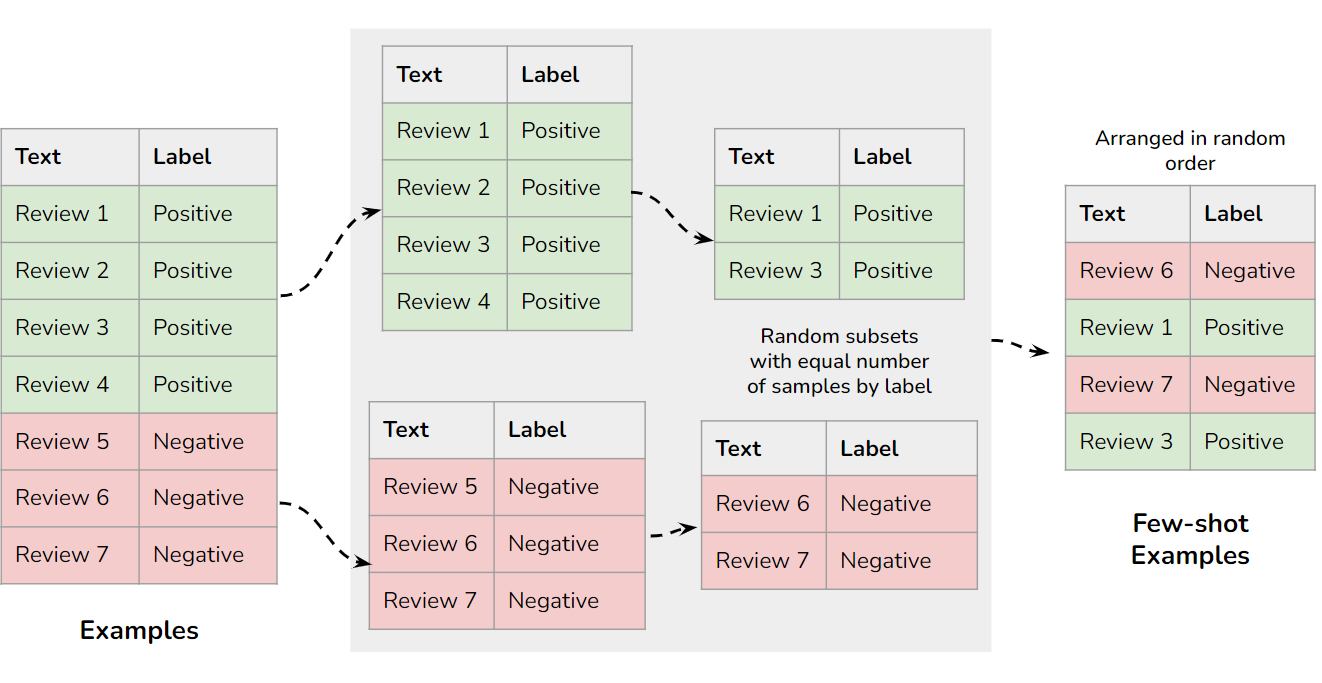

In [59]:
def create_examples(dataset, n=4):
    positive_reviews = (dataset.sentiment == 'positive')
    negative_reviews = (dataset.sentiment == 'negative')
    columns_to_select = ['text', 'sentiment']
    positive_examples = dataset.loc[positive_reviews, columns_to_select].sample(n)
    negative_examples = dataset.loc[negative_reviews, columns_to_select].sample(n)
    examples = pd.concat([positive_examples, negative_examples])
    # sampling without replacement is equivalent to random shuffling
    randomized_examples = examples.sample(2*n, replace=False)
    return randomized_examples.to_json(orient='records')

In [60]:
examples = create_examples(examples_df, 2)

In [61]:
json.loads(examples)

[{'text': '"The Days" is a typical family drama with a little catch - you must relate to the character\'s emotions in every way possible in order for you to truly appreciate the show.<br /><br />[Possible Spoilers For Those Who Are Unfamiliar With the Show]<br /><br />The story, obviously, for all the people who has watched the show, is the world of Cooper Day, the middle child of the family. He records his days with his family and hopes to become a rich and famous writer one day because of his observations. His family includes a mother, a father, a perfect sister, and a genius-little-brother. The first episode, which is going to sound a bit stupid since John Scott Shepard has created this situation - both the sister and mother gets pregnant. That\'s the first situation the writer hits. Then the father quits his job at the law firm. The youngest son gets a panic attack. The middle child gets in a fight with the sister\'s boyfriend. This is all in a day\'s work.<br /><br />[/Spoilers]<b

# Constructing Few-Shot Prompts

## Leveraging Examples for Better Performance

Few-shot learning provides context through examples, improving LLM accuracy without fine-tuning.

### Few-Shot Prompt Structure:
1. **System Message**: Task definition and instructions
2. **Examples**: Input-output pairs demonstrating desired behavior
3. **Test Input**: The actual text to classify

### Benefits:
- **Context**: Examples clarify task requirements
- **Consistency**: Demonstrates expected output format
- **Adaptability**: Works across different domains

We'll create a reusable function to generate these structured prompts programmatically.

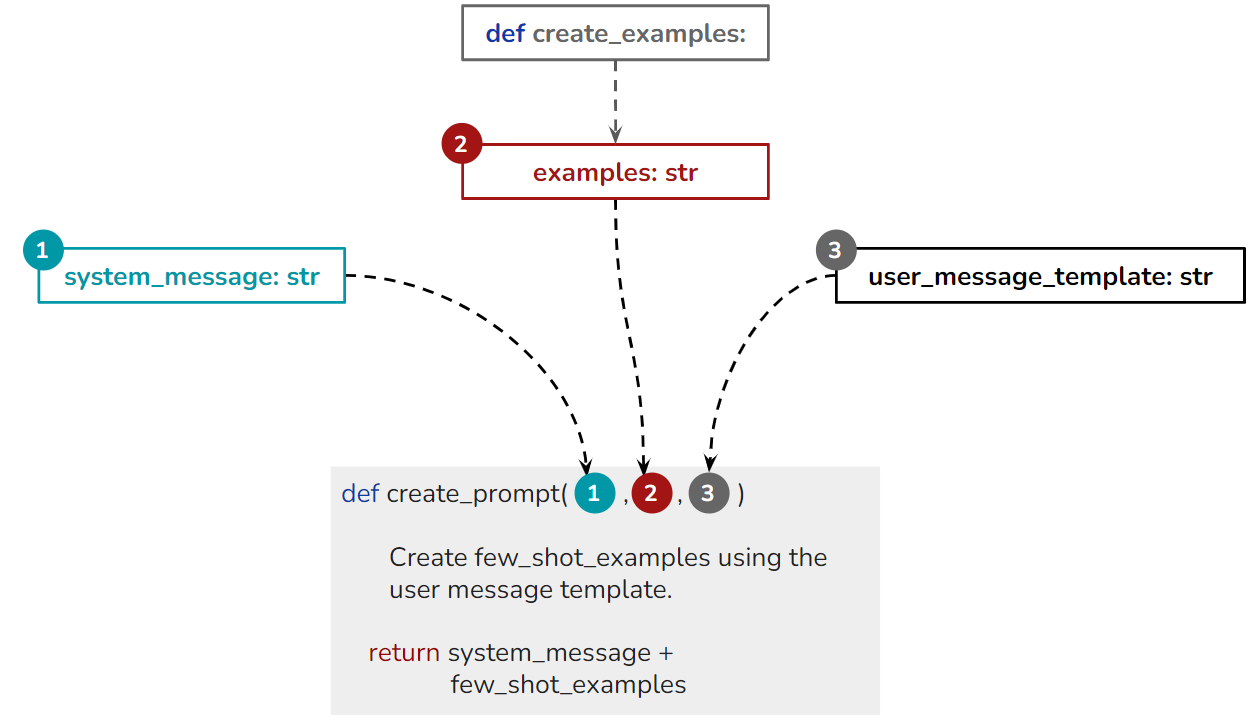

In [62]:
def create_prompt(system_message, examples, user_message_template):
    few_shot_prompt = [{'role':'system', 'content': system_message}]
    for example in json.loads(examples):
        example_review = example['text']
        example_sentiment = example['sentiment']
        few_shot_prompt.append(
            {
                'role': 'user',
                'content': user_message_template.format(
                    movie_review=example_review
                )
            }
        )
        few_shot_prompt.append(
            {'role': 'assistant', 'content': f"{example_sentiment}"}
        )
    return few_shot_prompt

In [63]:
few_shot_prompt = create_prompt(
    few_shot_system_message,
    examples,
    user_message_template
)

In [64]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': '```"The Days" is a typical family drama with a little catch - you must relate to the character\'s emotions in every way possible in order for you to truly appreciate the show.<br /><br />[Possible Spoilers For Those Who Are Unfamiliar With the Show]<br /><br />The story, obviously, for all the people who has watched the show, is the world of Cooper Day, the middle child of the family. He records his days with his family and hopes to become a rich and famous writer one day because of his observations. His family includes a mother, a father, a perfect sister, and a genius-little-brother. The first episode, which is going to sound a bit stupid since John Scott Shepard has created this situation -

**Prompt 3: Chain-of-Thought**

For the CoT prompt, we add detailed step-by-step instructions to the few shot system message instructing the model to carefully ponder before assigning sentiment. Apart from this addition, there are no further changes from the few-shot prompt.

In [65]:
cot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.

Instructions:
1. Carefully read the text of the review and think through the options for sentiment provided
2. Consider the overall sentiment of the review and estimate the probability of the review being positive

To reiterate, your answer should strictly only contain the label: positive or negative
"""

In [66]:
cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)

In [67]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative' \nDo not explain your answer.\n\nInstructions:\n1. Carefully read the text of the review and think through the options for sentiment provided\n2. Consider the overall sentiment of the review and estimate the probability of the review being positive\n\nTo reiterate, your answer should strictly only contain the label: positive or negative\n"},
 {'role': 'user',
  'content': '```"The Days" is a typical family drama with a little catch - you must relate to the character\'s emotions in every way possible in order for you to truly appreciate the show.<br /><br />[Possible Spoilers For Those Who Are Unfamiliar With the Show]<br /><br />The story, obviously, for all the people who has watched the show, is the world of Cooper Day, the middle child of the family. 

Note that the examples remain the same while the system message changes.

#### Evaluate prompts

Now we have three sets of prompts that we need to evaluate using gold labels. Since the few-shot prompt and the CoT prompt depend on the sample of examples that was drawn to make up the prompt, we expect some variability in evaluation. Hence, we evaluate each prompt multiple times to get a sense of the average and the variation around the average.

To reiterate, a choice on the prompt should account for variability due to the choice of the random sample. To aid repeated evaluation, we assemble an evaluation function (overall logic depicted in the figure below).

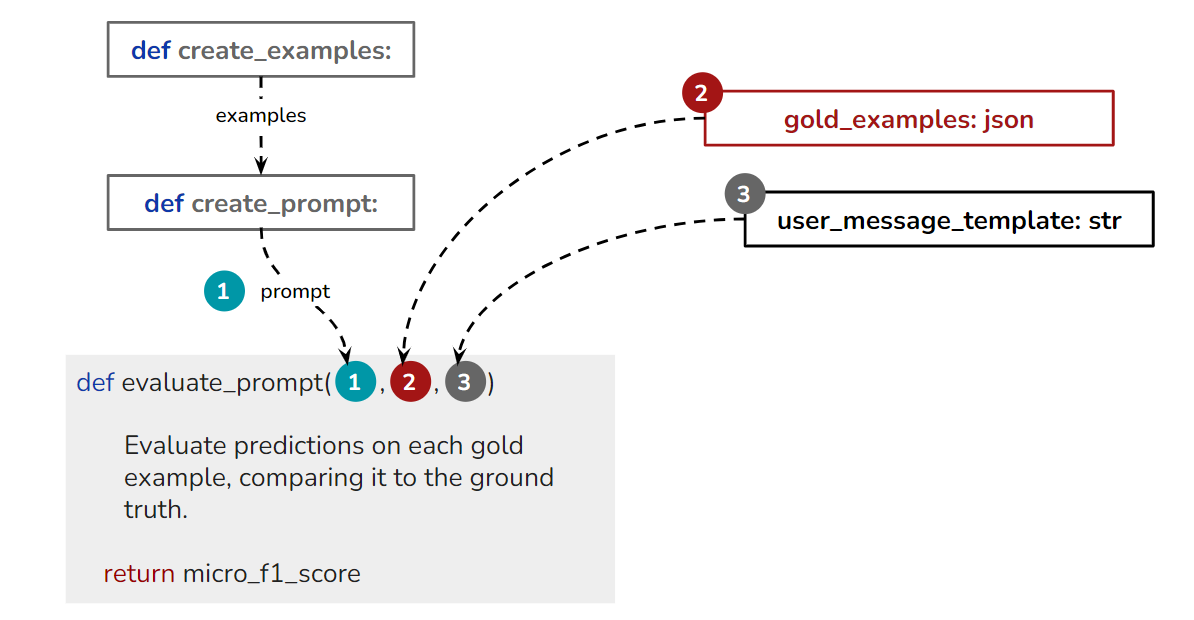

In [68]:
def evaluate_prompt(prompt, gold_examples, user_message_template, model):
    model_predictions, ground_truths = [], []

    for example in json.loads(gold_examples):
        gold_input = example['text']
        user_input = [
            {
                'role':'user',
                'content': user_message_template.format(movie_review=gold_input)
            }
        ]

        try:
            response = model.invoke(
               prompt+user_input
            )
            if hasattr (response, 'content'):
                response_content = response.content
            else:
                response_content = response    
            if 'negative' in response_content.strip().lower():
                prediction='negative'
            elif 'positive' in response_content.strip().lower():
                prediction='positive'
            else:
                prediction ='unknown'
            model_predictions.append(prediction)
            ground_truths.append(example['sentiment'])
            #print(prediction, example['sentiment'])

        except Exception as e:
            print(e)
            continue

    micro_f1_score = f1_score(ground_truths, model_predictions, average="micro")

    return micro_f1_score

Let us now use this function to do one evaluation of all the three prompts assembled so far, each time computing the Micro-F1 score.

In [69]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template, gpt4_llm)

1.0

In [70]:
evaluate_prompt(few_shot_prompt, gold_examples, user_message_template, gpt4_llm)

1.0

In [71]:
evaluate_prompt(cot_few_shot_prompt, gold_examples, user_message_template, gpt4_llm)

1.0

However, this is just *one* choice of examples. We will need to run these evaluations with multiple choices of examples to get a sense of variability in F1 score for the few-shot prompt and the CoT prompt. As an example, let us run evaluations for the few-shot prompt and the CoT prompt 10 times.

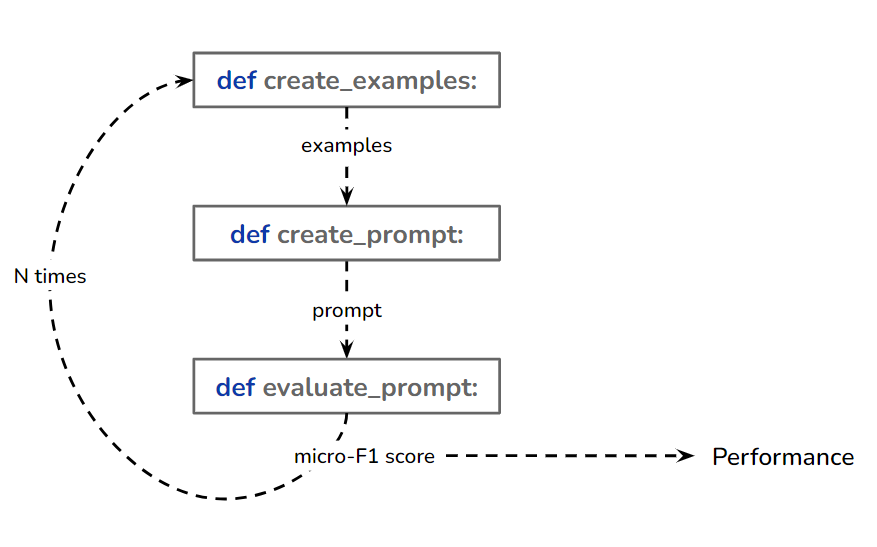

In [72]:
num_eval_runs = 10

In [73]:
few_shot_performance, cot_few_shot_performance = [], []

In [74]:
for _ in tqdm(range(num_eval_runs)):

    # For each run create a new sample of examples
    examples = create_examples(examples_df)

    # Assemble the few shot prompt with these examples
    few_shot_prompt = create_prompt(few_shot_system_message, examples, user_message_template)
    #cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)

    # Evaluate prompt accuracy on gold examples
    few_shot_micro_f1 = evaluate_prompt(few_shot_prompt, gold_examples, user_message_template, gpt4_llm)
    #cot_few_shot_micro_f1 = evaluate_prompt(cot_few_shot_prompt, gold_examples, user_message_template)

    few_shot_performance.append(few_shot_micro_f1)
    cot_few_shot_performance.append(few_shot_micro_f1)

100%|██████████| 10/10 [02:16<00:00, 13.70s/it]


In [75]:
np.array(few_shot_performance).mean(), np.array(few_shot_performance).std()

(1.0, 0.0)